In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
!unzip '/content/drive/MyDrive/Group C.zip'

Archive:  /content/drive/MyDrive/Group C.zip
   creating: Group C/
   creating: Group C/Gem_End/
  inflating: Group C/Gem_End/AHCR_00001_Gem_End_12.jpg  
  inflating: Group C/Gem_End/AHCR_00001_Gem_End_13.jpg  
  inflating: Group C/Gem_End/AHCR_00001_Gem_End_4.jpg  
  inflating: Group C/Gem_End/AHCR_00001_Gem_End_5.jpg  
  inflating: Group C/Gem_End/AHCR_00002_Gem_End_12.jpg  
  inflating: Group C/Gem_End/AHCR_00002_Gem_End_13.jpg  
  inflating: Group C/Gem_End/AHCR_00002_Gem_End_4.jpg  
  inflating: Group C/Gem_End/AHCR_00002_Gem_End_5.jpg  
  inflating: Group C/Gem_End/AHCR_00003_Gem_End_12.jpg  
  inflating: Group C/Gem_End/AHCR_00003_Gem_End_13.jpg  
  inflating: Group C/Gem_End/AHCR_00003_Gem_End_4.jpg  
  inflating: Group C/Gem_End/AHCR_00003_Gem_End_5.jpg  
  inflating: Group C/Gem_End/AHCR_00004_Gem_End_12.jpg  
  inflating: Group C/Gem_End/AHCR_00004_Gem_End_13.jpg  
  inflating: Group C/Gem_End/AHCR_00004_Gem_End_4.jpg  
  inflating: Group C/Gem_End/AHCR_00004_Gem_End_5.jpg  

In [40]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group C"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path): 
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 3417, Testing samples: 855
Number of classes: 9


In [43]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [44]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.1019 - loss: 2.2508 - val_accuracy: 0.2608 - val_loss: 1.9014
Epoch 2/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.2120 - loss: 1.9853 - val_accuracy: 0.3216 - val_loss: 1.6197
Epoch 3/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.2767 - loss: 1.7893 - val_accuracy: 0.3789 - val_loss: 1.5094
Epoch 4/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.3220 - loss: 1.6580 - val_accuracy: 0.4620 - val_loss: 1.3797
Epoch 5/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.3464 - loss: 1.6096 - val_accuracy: 0.5029 - val_loss: 1.2744
Epoch 6/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3960 - loss: 1.5446 - val_accuracy: 0.5322 - val_loss: 1.2389
Epoch 7/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.4406 - loss: 1.4539 - val_accuracy: 0.6023 - val_loss: 1.1086
Epoch 8/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5100 - loss: 1.3144 - val_accuracy: 0

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8840 - loss: 0.3705
Train Accuracy: 82.56%
Test Accuracy: 88.19%


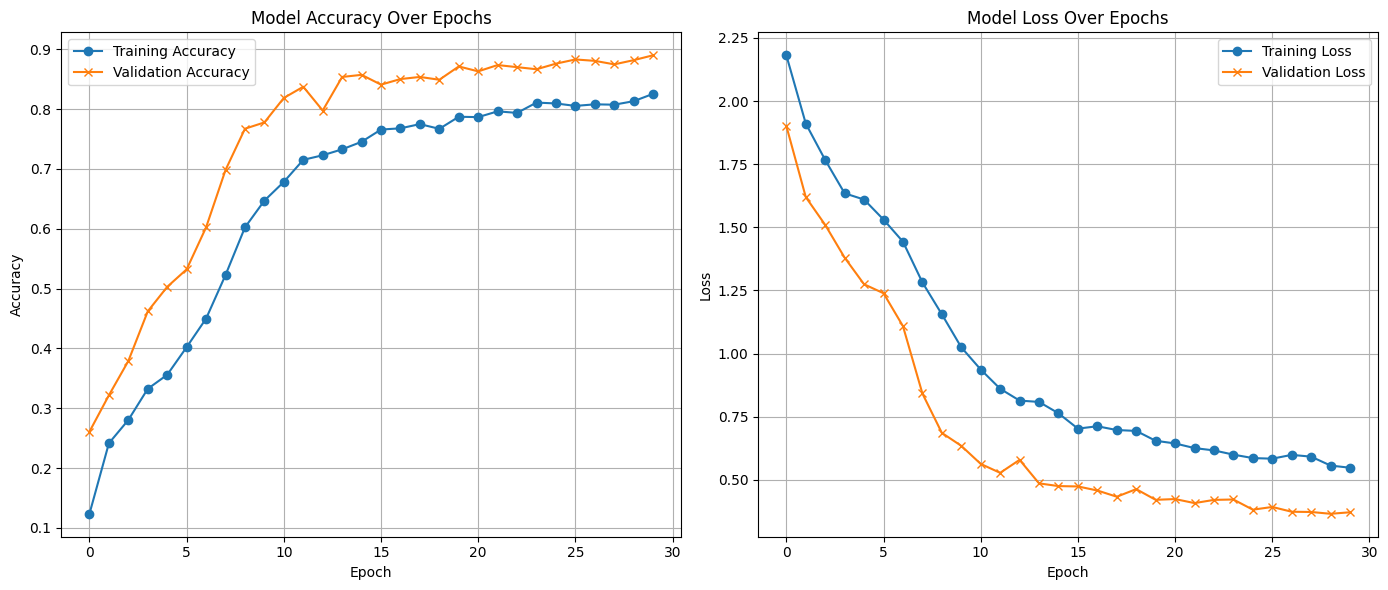

In [46]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


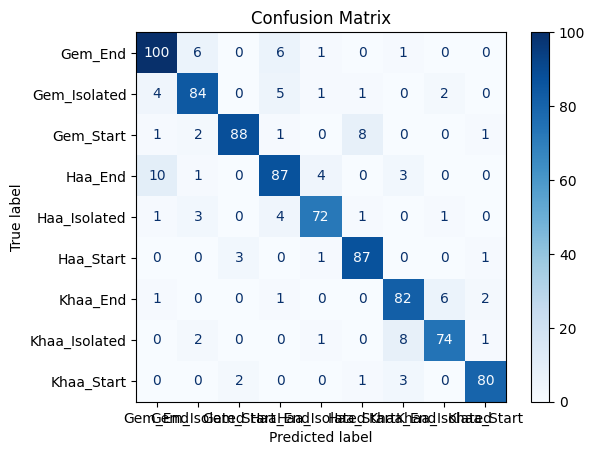

Number of incorrect predictions: 101


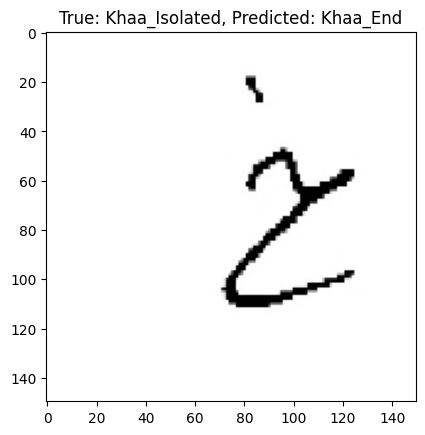

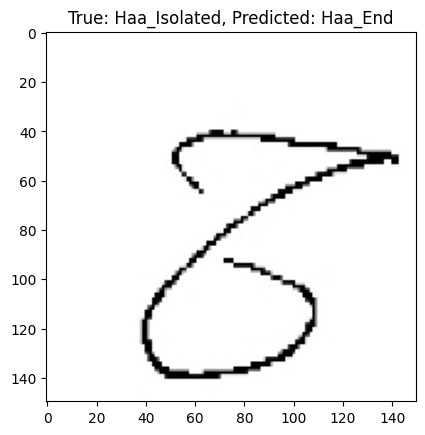

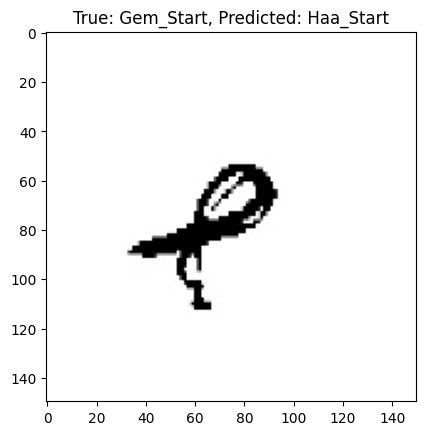

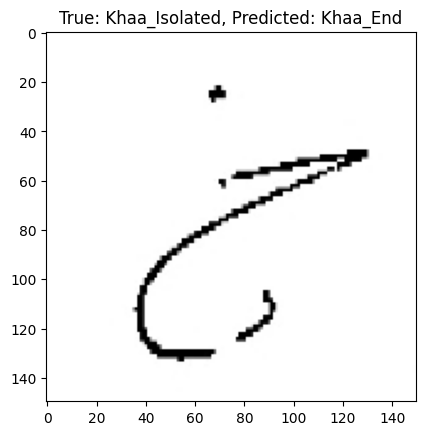

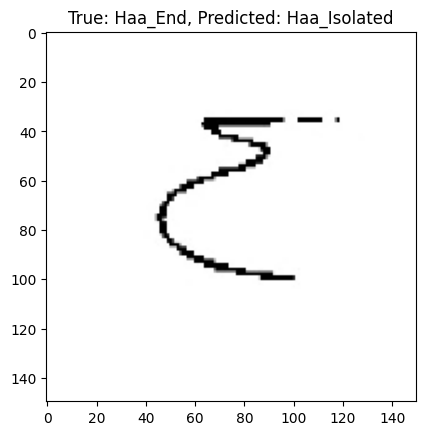

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease dropout and decrease epochs 

In [48]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [49]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=28,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.1454 - loss: 2.1798 - val_accuracy: 0.3018 - val_loss: 1.6617
Epoch 2/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.3371 - loss: 1.6771 - val_accuracy: 0.4947 - val_loss: 1.3223
Epoch 3/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.4962 - loss: 1.3713 - val_accuracy: 0.6807 - val_loss: 0.9435
Epoch 4/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.6429 - loss: 1.0271 - val_accuracy: 0.7415 - val_loss: 0.7143
Epoch 5/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7146 - loss: 0.8337 - val_accuracy: 0.7813 - val_loss: 0.6222
Epoch 6/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7542 - loss: 0.7382 - val_accuracy: 0.8012 - val_loss: 0.6025
Epoch 7/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7820 - loss: 0.6324 - val_accuracy: 0.8304 - val_loss: 0.5178
Epoch 8/28
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8135 - loss: 0.6121 - val_accuracy: 0

In [51]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8896 - loss: 0.3444
Train Accuracy: 89.93%
Test Accuracy: 90.06%


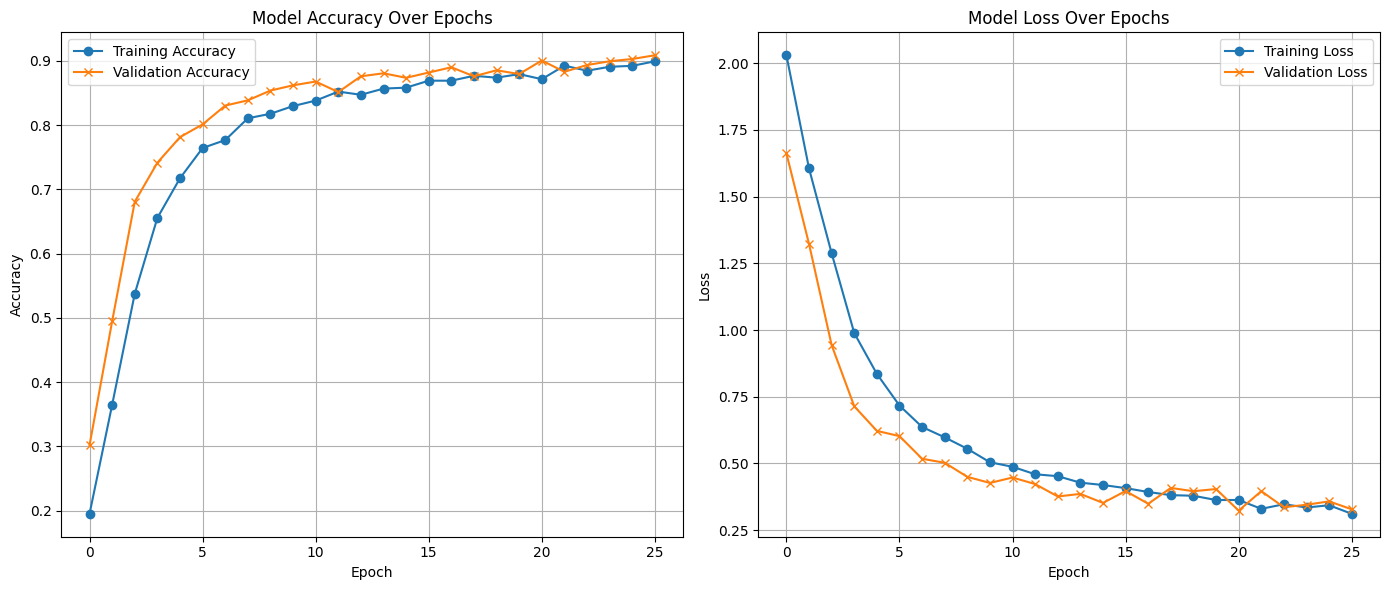

In [52]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


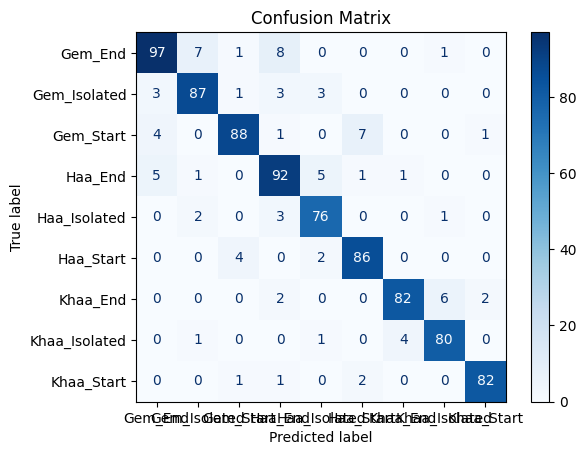

Number of incorrect predictions: 85


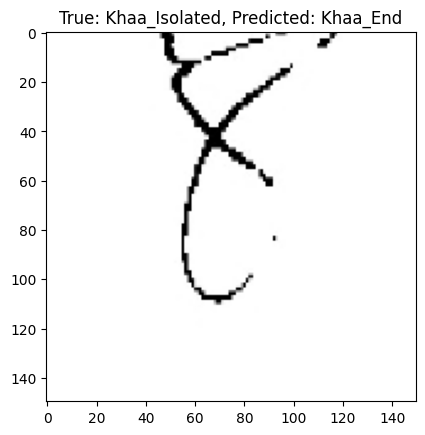

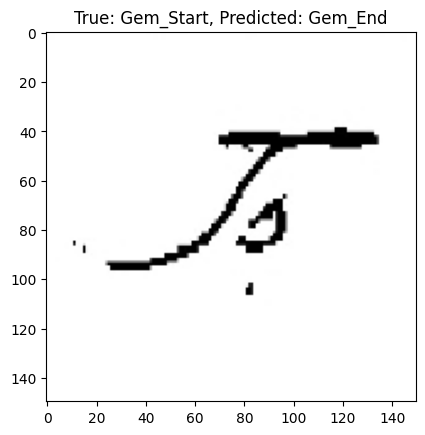

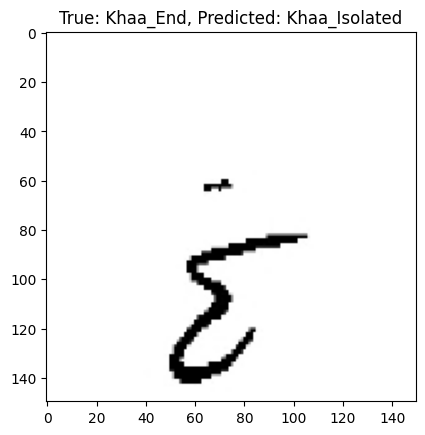

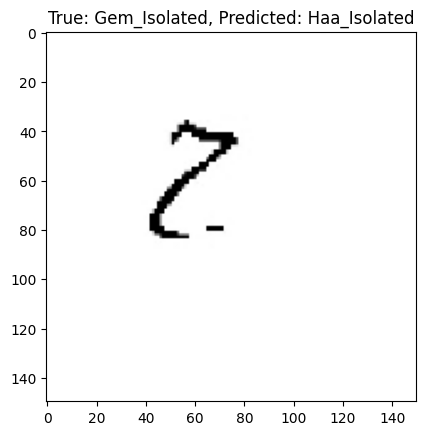

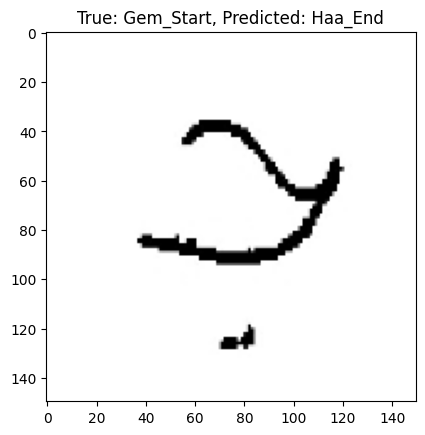

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### remove dropOut and increase epochs 

In [55]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [56]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(123, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.1536 - loss: 2.1698 - val_accuracy: 0.3181 - val_loss: 1.6132
Epoch 2/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.3212 - loss: 1.6731 - val_accuracy: 0.4222 - val_loss: 1.4642
Epoch 3/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.4179 - loss: 1.4972 - val_accuracy: 0.5766 - val_loss: 1.1234
Epoch 4/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5574 - loss: 1.2087 - val_accuracy: 0.7053 - val_loss: 0.8244
Epoch 5/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.6879 - loss: 0.9391 - val_accuracy: 0.7649 - val_loss: 0.7321
Epoch 6/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7232 - loss: 0.8218 - val_accuracy: 0.7801 - val_loss: 0.6590
Epoch 7/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.7605 - loss: 0.7322 - val_accuracy: 0.8094 - val_loss: 0.5926
Epoch 8/30
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7811 - loss: 0.6891 - val_accuracy: 0.8

In [58]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8742 - loss: 0.3899
Train Accuracy: 90.11%
Test Accuracy: 88.54%


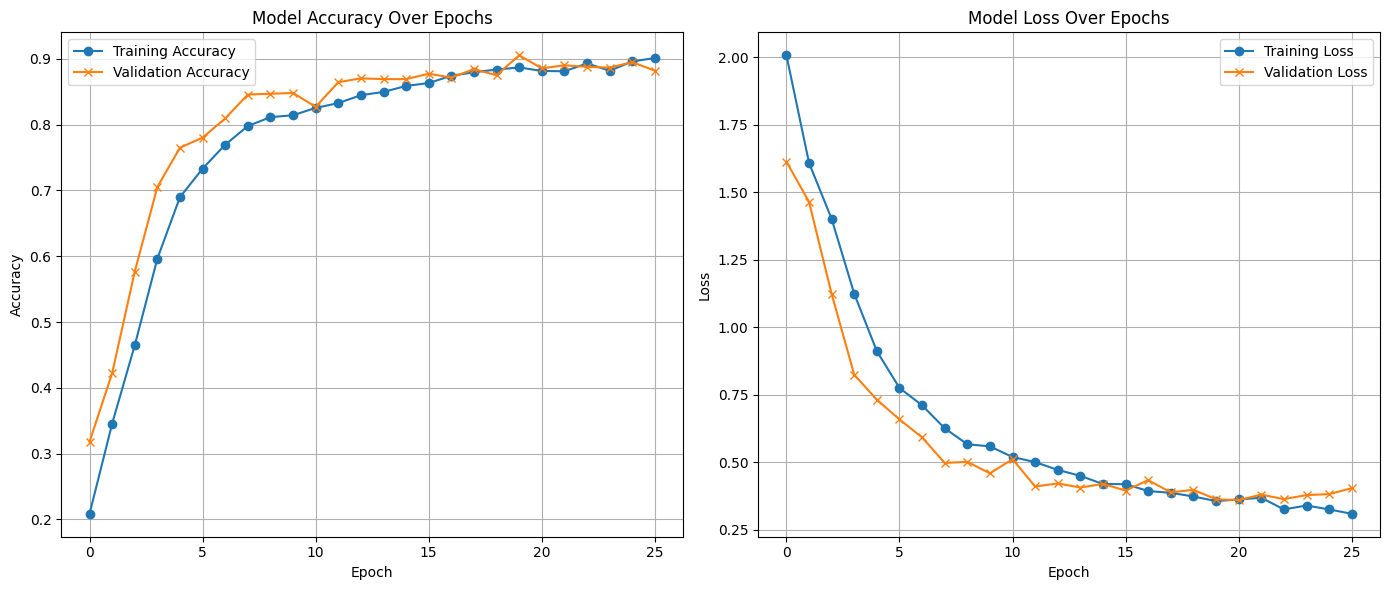

In [61]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


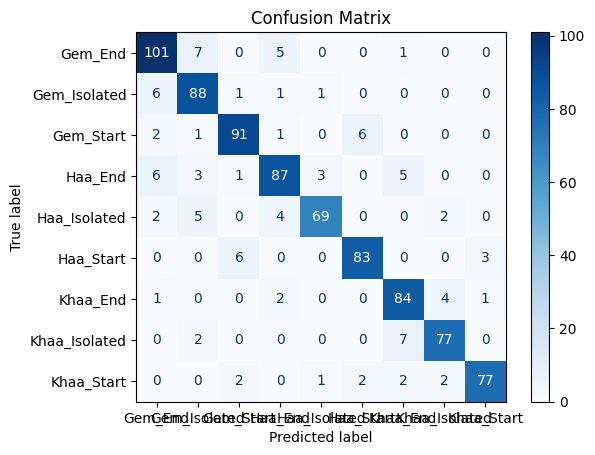

Number of incorrect predictions: 98


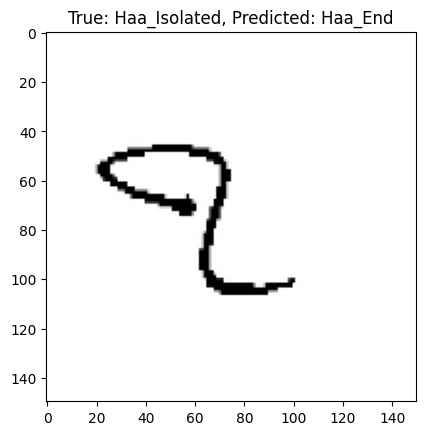

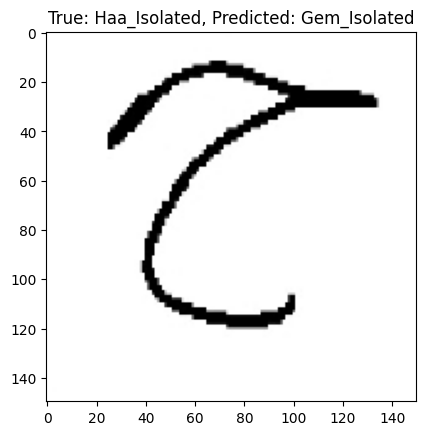

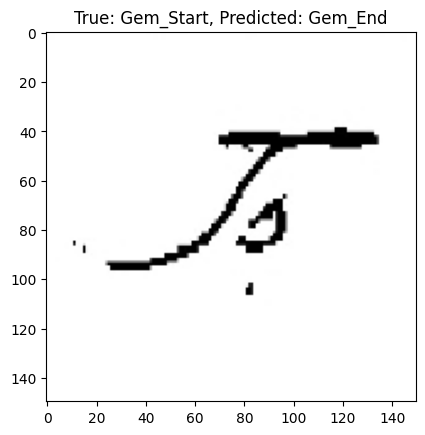

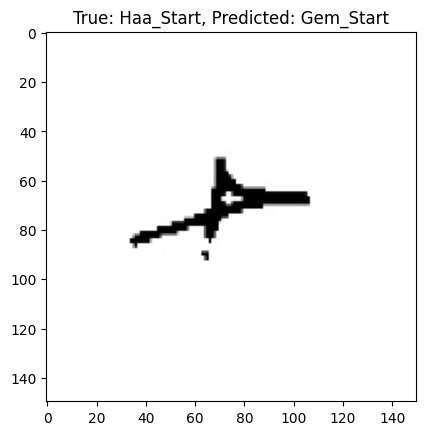

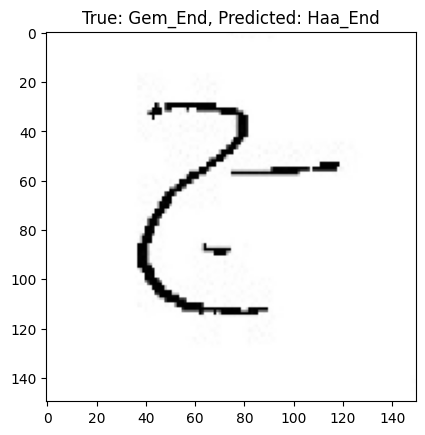

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### increase epochs (more training)

In [63]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=10,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


214/214 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8834 - loss: 0.3689 - val_accuracy: 0.8772 - val_loss: 0.3906
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8889 - loss: 0.3613 - val_accuracy: 0.8901 - val_loss: 0.3909
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8889 - loss: 0.3642 - val_accuracy: 0.9006 - val_loss: 0.3770
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8946 - loss: 0.3158 - val_accuracy: 0.8959 - val_loss: 0.3563
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8930 - loss: 0.2980 - val_accuracy: 0.9006 - val_loss: 0.3532
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9012 - loss: 0.3110 - val_accuracy: 0.9018 - val_loss: 0.3442
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9002 - loss: 0.3031 - val_accuracy: 0.9088 - val_loss: 0.3479
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9062 - loss: 0.2995 - val_accuracy: 0

In [68]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9070 - loss: 0.3462
Train Accuracy: 90.17%
Test Accuracy: 90.18%


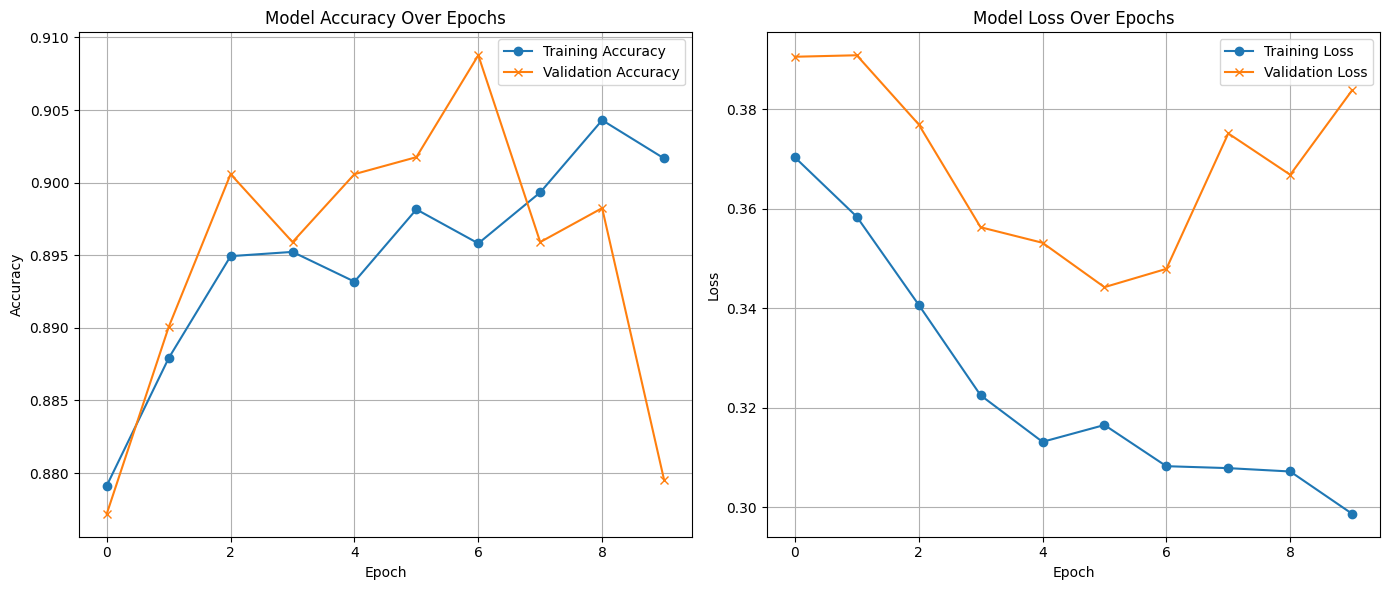

In [69]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


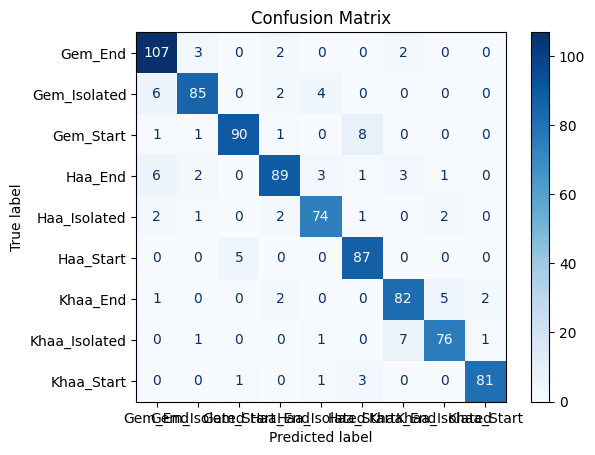

Number of incorrect predictions: 84


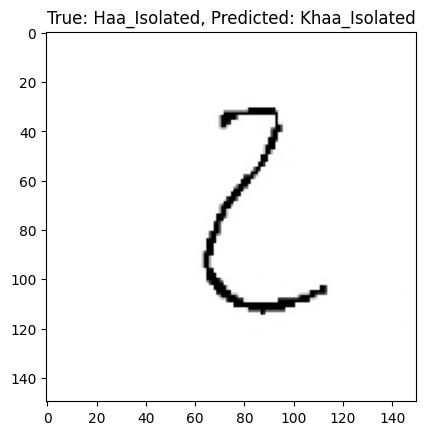

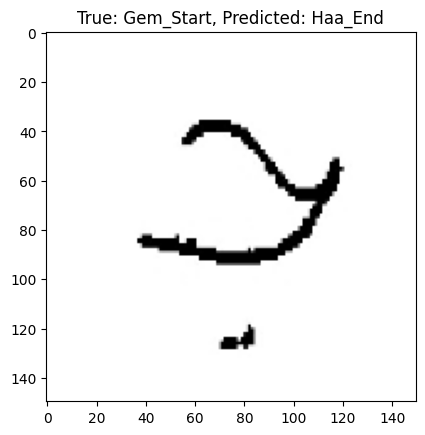

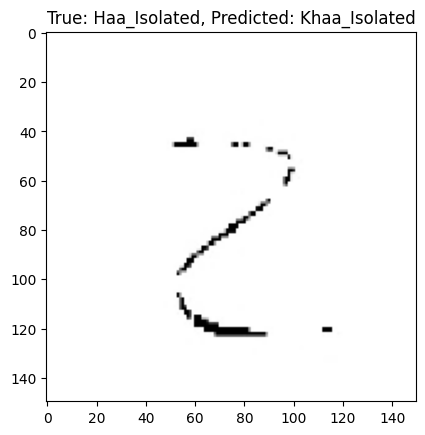

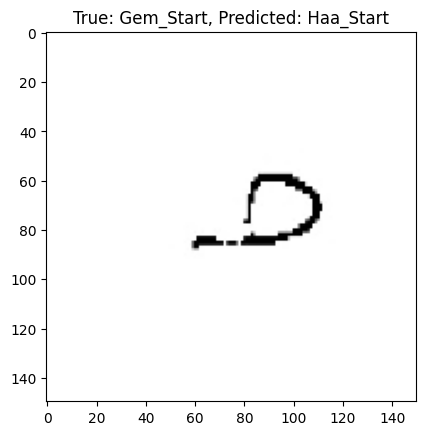

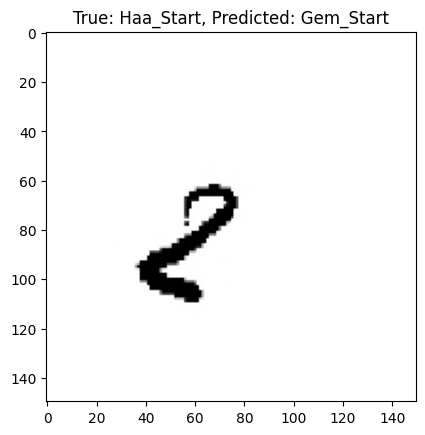

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [71]:
model.save("GrpC.keras")